In [35]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score
)

# Get the absolute path to the file
current_dir = os.getcwd()
parent_dir = os.path.dirname(current_dir)  # Go up one directory
file_path = os.path.join(parent_dir, "output_csv_files", "ward_temporal_analysis.csv")

# Load and prepare data
df = pd.read_csv(file_path, parse_dates=['Month'])
df['Month'] = pd.to_datetime(df['Month'], errors='coerce')
df = df.dropna()

# Extract year and numeric month
df['Year'] = df['Month'].dt.year
df['Month_Num'] = df['Month'].dt.month

# Rename columns to remove spaces
df = df.rename(columns={'Ward ID': 'Ward_ID'})

# Create lag features
def create_lag_features(df, lag_periods=[1, 2, 3]):
    """
    Create lag features for crime density
    Parameters:
    -----------
    df : pandas DataFrame
        Input dataframe with time series data
    lag_periods : list
        List of lag periods to create
    Returns:
    --------
    pandas DataFrame with added lag features
    """
    # Sort the dataframe by Ward_ID, Year, and Month_Num
    df = df.sort_values(['Ward_ID', 'Year', 'Month_Num'])
    
    # Create lag features for each ward separately
    for ward in df['Ward_ID'].unique():
        ward_mask = df['Ward_ID'] == ward
        for lag in lag_periods:
            df.loc[ward_mask, f'Crime_Density_Lag_{lag}'] = df.loc[ward_mask, 'Monthly_Crime_Density'].shift(lag)
    
    return df

# Create lag features
df_with_lags = create_lag_features(df)

# Encode Ward_ID
le = LabelEncoder()
df_with_lags['Ward_ID_Encoded'] = le.fit_transform(df_with_lags['Ward_ID'])

# Define features
lag_features = [f'Crime_Density_Lag_{lag}' for lag in [1, 2, 3]]
features = ['Ward_ID_Encoded', 'Year', 'Month_Num'] + lag_features

# Train-test split
df_train = df_with_lags[df_with_lags['Year'] <= 2024]
df_test = df_with_lags[df_with_lags['Year'] > 2024]

# Drop rows with NaN values in any of the features
df_train = df_train.dropna(subset=features + ['Monthly_Crime_Density'])
df_test = df_test.dropna(subset=features + ['Monthly_Crime_Density'])

X_train = df_train[features]
y_train = df_train['Monthly_Crime_Density']
X_test = df_test[features]
y_test = df_test['Monthly_Crime_Density']

# Train Linear Regression Model
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

# Make Predictions
y_train_pred = lr_model.predict(X_train)
y_test_pred = lr_model.predict(X_test)

# Evaluation Function
def evaluate_model(y_true, y_pred, dataset_name=""):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    print(f"\n{dataset_name} Evaluation:")
    print(f"RMSE: {rmse:.2f}")
    print(f"MAE: {mae:.2f}")
    print(f"R² Score: {r2:.2f}")
    return rmse, mae, r2

# Evaluate Model
evaluate_model(y_train, y_train_pred, "Training Set")
evaluate_model(y_test, y_test_pred, "Test Set")

# Create a DataFrame with feature importance
feature_importance = pd.DataFrame({
    'Feature': features,
    'Coefficient': lr_model.coef_,
    'Abs_Coefficient': np.abs(lr_model.coef_)
})

# Sort by absolute coefficient value
feature_importance = feature_importance.sort_values('Abs_Coefficient', ascending=False)

# Print feature importance
print("\nFeature Importance (sorted by absolute coefficient value):")
print(feature_importance[['Feature', 'Coefficient']].to_string(index=False))


Training Set Evaluation:
RMSE: 4.67
MAE: 2.03
R² Score: 0.82

Test Set Evaluation:
RMSE: 4.04
MAE: 2.06
R² Score: 0.87

Feature Importance (sorted by absolute coefficient value):
            Feature  Coefficient
Crime_Density_Lag_1     0.326814
Crime_Density_Lag_3     0.319104
Crime_Density_Lag_2     0.304868
          Month_Num     0.017129
               Year     0.008816
    Ward_ID_Encoded    -0.000315


In [ ]:
# Visualization of feature coefficients gives you the information about how much and how each feature affects your target variable

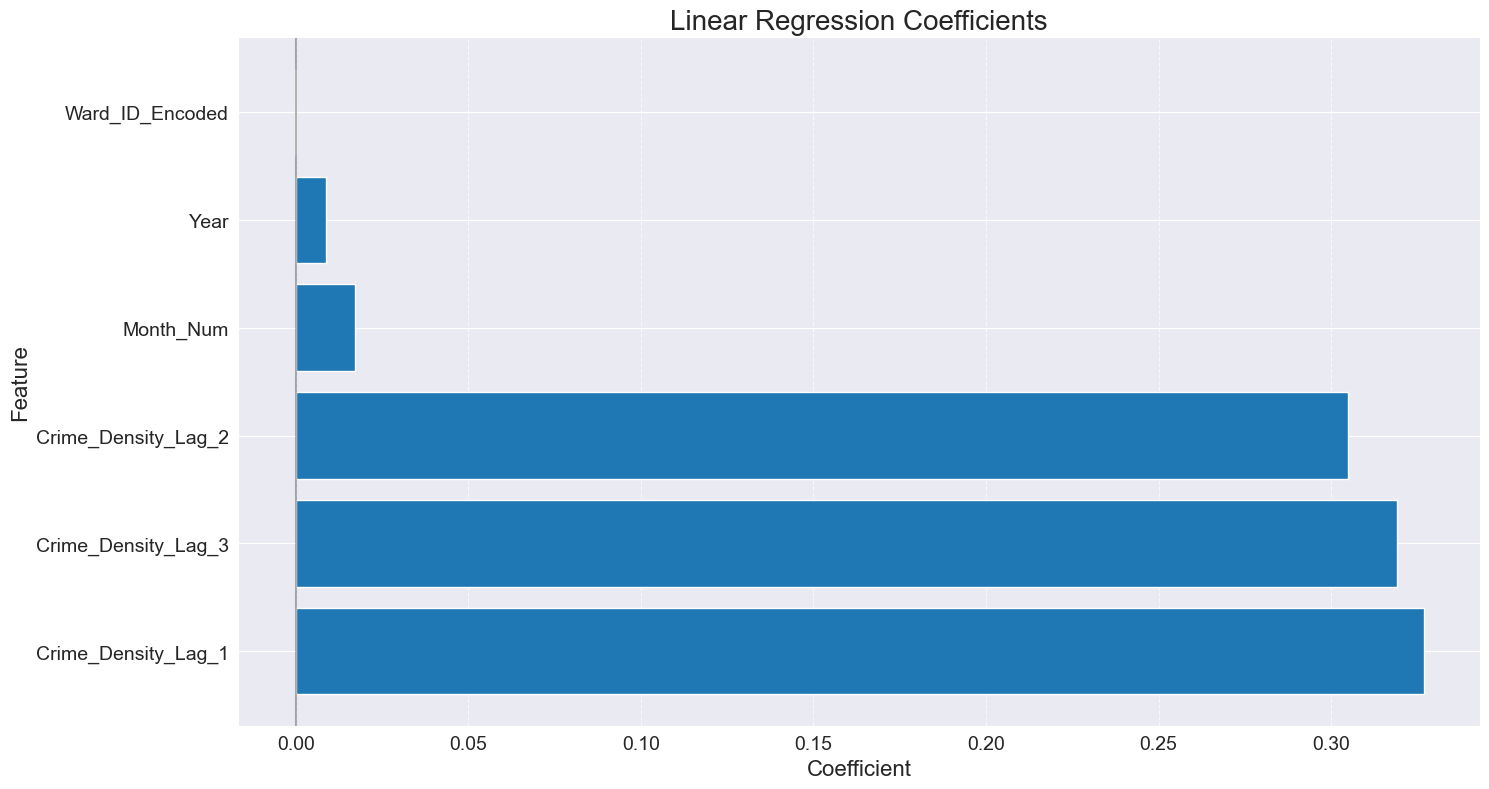

In [40]:
# Visualization of feature coefficients
plt.figure(figsize=(15, 8))

# Create horizontal bar plot
plt.barh(feature_importance['Feature'], feature_importance['Coefficient'])

# Increase font sizes
plt.title('Linear Regression Coefficients', fontsize=20)
plt.xlabel('Coefficient', fontsize=16)
plt.ylabel('Feature', fontsize=16)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)

# Add vertical line at x=0
plt.axvline(x=0, color='black', linestyle='-', alpha=0.3)

# Add grid for better readability
plt.grid(True, axis='x', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

In [ ]:
# Correlation Matrix between features and target

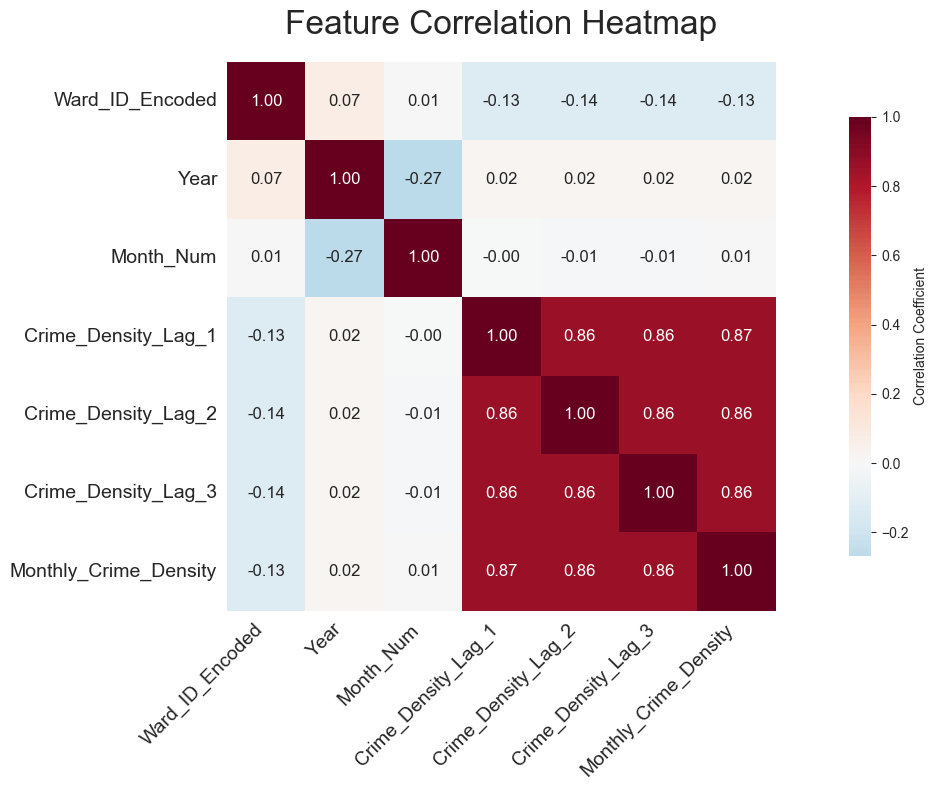

In [41]:
# Create correlation matrix
correlation_matrix = df_with_lags[features + ['Monthly_Crime_Density']].corr()

# Create a larger figure
plt.figure(figsize=(15, 8))

# Create heatmap with better formatting
sns.heatmap(correlation_matrix, 
            annot=True,  # Show correlation values
            cmap='RdBu_r',  # Red-Blue diverging colormap
            center=0,  # Center the colormap at 0
            fmt='.2f',  # Format correlation values to 2 decimal places
            square=True,  # Make the plot square
            cbar_kws={'label': 'Correlation Coefficient', 'shrink': 0.8},
            annot_kws={'size': 12})  # Increase annotation font size

# Increase font sizes
plt.title('Feature Correlation Heatmap', fontsize=24, pad=20)
plt.xticks(fontsize=14, rotation=45, ha='right')
plt.yticks(fontsize=14)

# Add more space between labels and plot
plt.tight_layout()

# Show the plot
plt.show()

In [ ]:
# the high correlation doesnt matter within lag features and target since lags are created from past values and it will be used to predict the future. High correlation is expected since there is temporal continuity in crime patterns